purpose of notebook is to work with new prep and plot functions from new_integrating_playground.ipynb 

goal is to make these new functions work with current plot function to and eventually to isolate NIST rendering logic so it can be used with other formatting functions

In [12]:
import re
import matplotlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

import matplotlib.pyplot as plt

import io
from IPython.display import Image, display
import utils
import nist_codes

import matplotlib.patheffects as pe

import new_utils


import nist_helper

from PIL import Image as PILImage

In [13]:
H_SHEET = "h test.xlsx"

global df  
df = pd.read_excel(H_SHEET)

data_df = df

In [14]:
detection_col = '_raw_int'
int_col = '_adj_int'

In [15]:
def left_x(a, b):
    xleft = a - b / 2
    return xleft

def right_x(a, b):
    xright = a + b / 2
    return xright

In [16]:
def get_generic_type():
    global generic_type
    gen_type = (input('Choose Rendering: Raw or Normalised')).lower()
    if gen_type == 'raw' or gen_type == 'r':
        generic_type = 'raw'
    elif gen_type == 'normalised' or gen_type == 'norm' or gen_type == 'n':
        generic_type = 'normalised'
    
    print (generic_type)
    return generic_type

In [17]:
# ax. ... values don't pass when trad_spec_labels() is called
    # FIX: had to add parameters and pass them along in trad_spec()

def trad_spec_labels(
    fig,
    ax,
    x_min,
    x_max,
):
    new_utils.get_mode()
    new_utils.text_colour()

    global figure_bg_color
    global text_color
    
    if new_utils.mode == 'dark':
        figure_bg_color = 'black'
        text_color = new_utils.colour
    elif new_utils.mode == 'light':
        figure_bg_color = 'white'
        text_color = new_utils.colour
    print("mode:", new_utils.mode, ", fig bg colour:", figure_bg_color)

    fig.patch.set_facecolor(figure_bg_color)

    ax.set_facecolor('black')  
    ax.yaxis.set_visible(False)

    ax.set_xlabel(new_utils.x_title, color=text_color)

    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0,1)

In [18]:
def prep_trad_spec(
    data_df,
    force_nist,
    x_min,
    x_max,
    apply_descriptor_adjustments,

):

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[new_utils.wl_col] = pd.to_numeric(df_plot_data[new_utils.wl_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[new_utils.INT_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')


    # parse NIST-style cells
    parsed_intensity = df_plot_data[new_utils.INT_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[new_utils.wl_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[new_utils.wl_col] >= x_min) & (df_plot_data[new_utils.wl_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=new_utils.wl_col).reset_index(drop=True)

    # returns empty flag for empty datasets
    if df_plot_data.empty:
        return None, True 

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range


    # Success! Return the completed dataframe and False (do not exit early)
    return df_plot_data, False, has_any_nist


In [19]:
# needs to be updated to work with trad_spec(). ideally should be able to work with set_generic_type()


def plot(
    df_plot_data,
    nm_col,
    has_any_nist,
    prominence_percentage=0,     
    fig_size=utils.FIG_SIZE,
    min_brightness=0,
    peak_wavelengths=None,
    show_peak_labels=True,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    min_needle_max_width_nm=utils.MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=utils.MAX_NEEDLE_WIDTH,
    needle_shape_power=utils.NEEDLE_POWER_SHAPE,
    glow_width_multiplier=utils.GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=utils.DPI,
    peak_label_y_position=0,
    max_needle_y_scale=utils.MAX_Y_SCALE,
    label_min_norm_int=utils.LABEL_NORM_INT,
    apply_descriptor_adjustments = False,
):

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    trad_spec_labels(fig=fig, ax=ax, x_min=x_min, x_max=x_max)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        min_brightness = utils.DEFAULT_MIN_BRIGHT
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = utils.DEFAULT_PROM_PERC
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        get_generic_type()
        if generic_type == 'raw':
            glow_alpha = utils.DEFAULT_GLOW_ALPHA
            peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised' or generic_type == 'n':
            glow_alpha = utils.NORM_GLOW_ALPHA
            peak_label_y_position = utils.NORM_PEAK_LABEL_POSN

    # --- Peak Detection ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[new_utils.wl_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if generic_type=='raw' or generic_type == 'r':
            prominence_percentage = utils.DEFAULT_PROM_PERC
        if generic_type == 'normalised' or generic_type == 'n':
            prominence_percentage = utils.NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[new_utils.INT_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][new_utils.wl_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)
    
    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")

    max_label_y = max(label_ys) if label_ys else peak_label_y_position
    print(f"DEBUG: max_label_y = {max_label_y:.3f}, fig height = {fig.get_figheight():.2f}")
    
    # More aggressive expansion
    ylim_upper = max(1.05, max_label_y + 0.25)
    ax.set_ylim(0, ylim_upper)
    fig.set_figheight(fig_size[1] + 0.8)
    print(f"DEBUG: new ylim upper = {ylim_upper:.3f}, new fig height = {fig.get_figheight():.2f}")


    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = new_utils.final_scale(min_brightness, _ni)
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = left_x(_nm, _bg_widths)
        _x_right = right_x(_nm, _bg_widths)
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or generic_type == 'raw' or generic_type == 'r':
            _peak_emphasis = utils.DEFAULT_PEAK_EMPHASIS
            min_brightness = utils.DEFAULT_MIN_BRIGHT
        elif generic_type == 'normalised' or generic_type == 'norm' or generic_type == 'n':
            _peak_emphasis = utils.NORM_PEAK_EMPHASIS
            min_brightness = utils.NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        color_rgb = new_utils.colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = left_x(peak_nm, glow_current_widths_nm)
        glow_x_right = right_x(peak_nm, glow_current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = new_utils.dynamic_prominence(scaled_max_width_nm, width_profile_factor)
        x_left = left_x(peak_nm, current_widths_nm)
        x_right = right_x(peak_nm, current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or generic_type == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.title(f'{generic_type.capitalize()} Emission Spectrum Visualization ({new_utils.mode.capitalize()} Mode)', color=new_utils.colour, y=0.98, pad=pad)


    plt.close(fig)
    
    return fig, ax

In [20]:
def trad_spec(
    data_df,
    nm_col = None,
    int_col = None,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    fig_size=utils.FIG_SIZE,
    dpi=utils.DPI,
    force_nist=None,
    apply_descriptor_adjustments = False,

):
   
    new_utils.res_col_names(data_df, nm_col=nm_col, int_col=int_col)

    
    df_plot_data, should_exit_early, has_any_nist = prep_trad_spec(data_df = data_df, 
                                                              force_nist = force_nist, 
                                                              x_min = x_min, 
                                                              x_max = x_max,
                                                              apply_descriptor_adjustments=apply_descriptor_adjustments,)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig
    

    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plot(df_plot_data = df_plot_data, nm_col = new_utils.wl_col, has_any_nist=has_any_nist)

    plt.close(fig)
    return fig

nm Grey Val
No NIST Destriptors Detected. Preparing Generic Rendering.


mode: light
text colour: black face/bg colour: white
mode: light , fig bg colour: white
normalised
DEBUG: max_label_y = 0.75
DEBUG: max_label_y = 0.750, fig height = 3.00
DEBUG: new ylim upper = 1.050, new fig height = 3.80


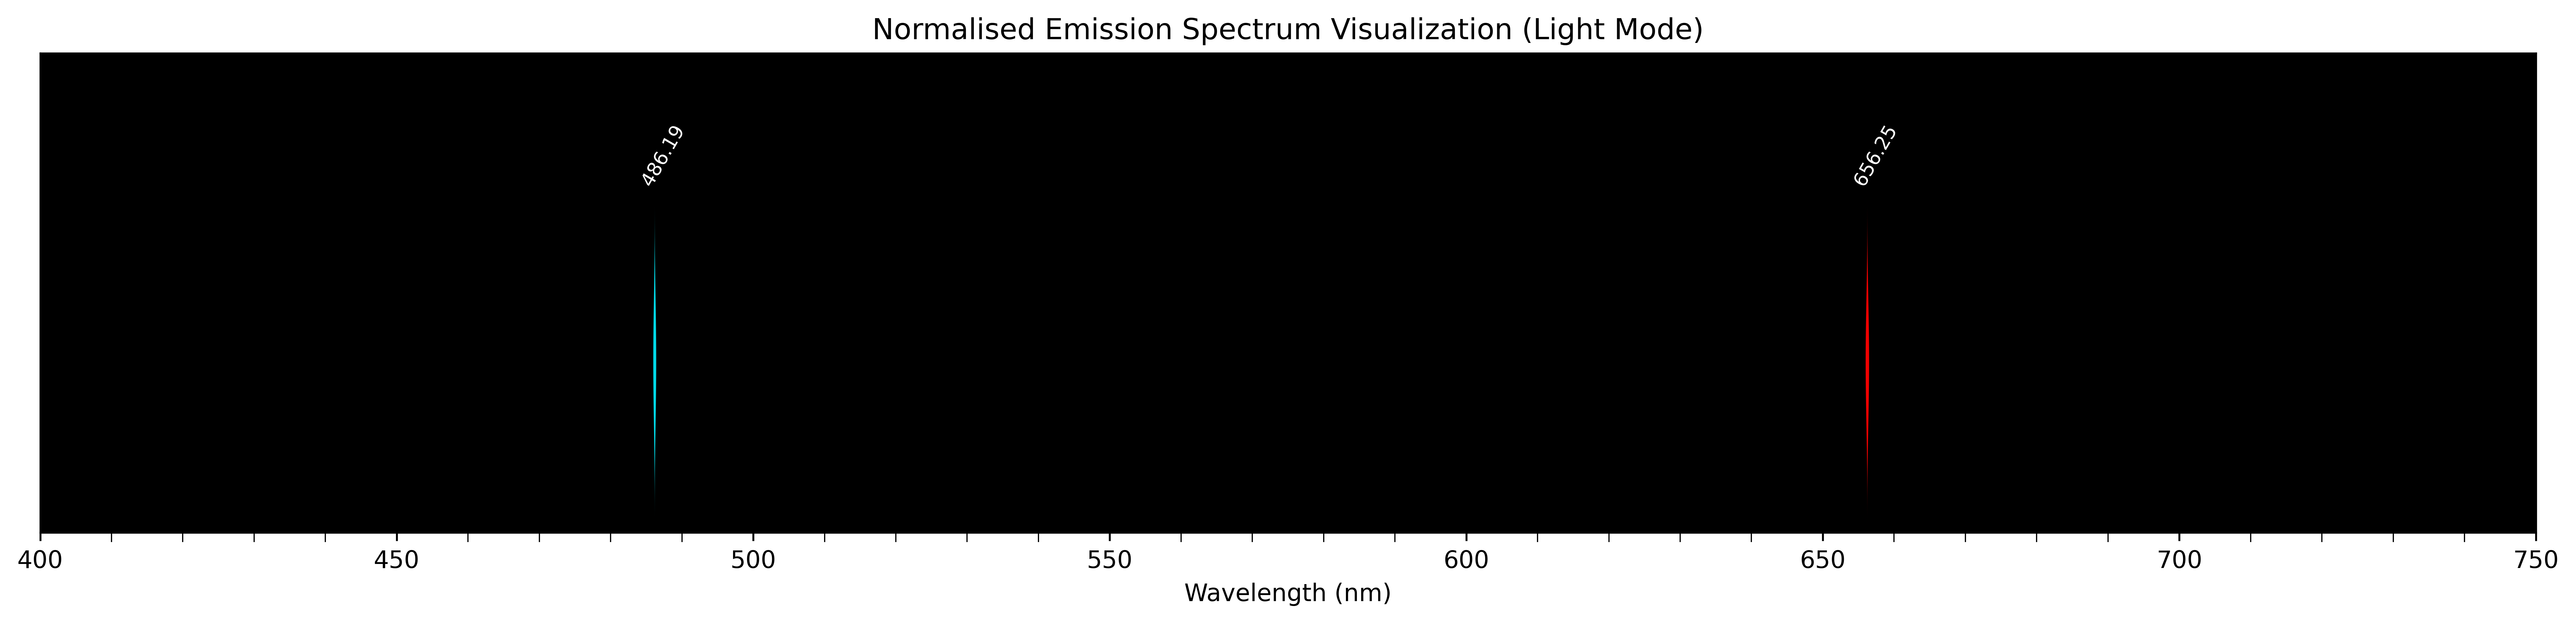

In [24]:
trad_spec(df)